# UVA Foreign Giving Analysis
**Beverley Appiatse**


In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("ForeignGifts_edu.csv", low_memory=False)

df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


In [20]:
df[df["Institution Name"].str.contains("Virginia", case=False, na=False)]["Institution Name"].unique()

array(['Virginia Commonwealth University', 'University of Virginia',
       'Virginia Polytechnic Institute & State University',
       'West Virginia University'], dtype=object)

In [21]:
uva = df[df["Institution Name"] == "University of Virginia"]

uva.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
26235,26236,374500,University of Virginia,Charlottesville,VA,41822,3565,Monetary Gift,ENGLAND,West Yorkshire Police
26236,26237,374500,University of Virginia,Charlottesville,VA,41870,12265,Contract,ISRAEL,CureTech Ltd
26237,26238,374500,University of Virginia,Charlottesville,VA,41873,8187,Monetary Gift,ISRAEL,Branco Weiss Institute
26238,26239,374500,University of Virginia,Charlottesville,VA,41887,6437,Contract,ISRAEL,NovoCure Ltd
26239,26240,374500,University of Virginia,Charlottesville,VA,41904,216943,Contract,ISRAEL,InSightec-Image Guide Treatment Ltd


In [22]:
uva.shape

(98, 10)

In [23]:
uva.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False)

Country of Giftor
BANGLADESH         4228589
SWEDEN             4007552
TANZANIA           2776447
SWITZERLAND        2000000
ENGLAND            1950666
GUERNSEY           1500000
FINLAND            1008384
BERMUDA             900000
KOREA               862787
SINGAPORE           805000
THE NETHERLANDS     725670
ISRAEL              623655
RWANDA              284135
JAPAN               265970
FRANCE              250383
Name: Foreign Gift Amount, dtype: int64

Bangladesh contributed the largest total amount to UVA with $4,228,589. It is followed by Sweden with $4,007,552 and Tanzania with $2,776,447.

In [24]:
uva.groupby("Country of Giftor")["Foreign Gift Amount"].count().sort_values(ascending=False)

Country of Giftor
ENGLAND            31
ISRAEL             12
BANGLADESH         10
SWEDEN             10
FINLAND             7
KOREA               6
FRANCE              5
THE NETHERLANDS     4
GUERNSEY            3
TANZANIA            3
SINGAPORE           2
SWITZERLAND         2
BERMUDA             1
JAPAN               1
RWANDA              1
Name: Foreign Gift Amount, dtype: int64

England has the greatest number of foreign gifts to UVA with 31 gifts. Bangladesh had 10 gifts

In [25]:
uva.groupby("Country of Giftor")["Foreign Gift Amount"].mean().sort_values(ascending=False)

Country of Giftor
SWITZERLAND        1000000.000000
TANZANIA            925482.333333
BERMUDA             900000.000000
GUERNSEY            500000.000000
BANGLADESH          422858.900000
SINGAPORE           402500.000000
SWEDEN              400755.200000
RWANDA              284135.000000
JAPAN               265970.000000
THE NETHERLANDS     181417.500000
FINLAND             144054.857143
KOREA               143797.833333
ENGLAND              62924.709677
ISRAEL               51971.250000
FRANCE               50076.600000
Name: Foreign Gift Amount, dtype: float64

Switzerland has the highest avergae gift amount to UVA at $1,000,000. It is followed by Tanzania at $925,482, and Bermuda at $900,000.

In [26]:
uva.groupby("Gift Type")["Foreign Gift Amount"].agg(["count", "sum", "mean"])

,count,sum,mean
Gift Type,,,
Contract,64,14807636,231369.312500
Monetary Gift,34,7381602,217105.941176


UVA received 64 contracts totaling at $1,4807,636 and 34 monetary gifts totaling at $7,381,602.

In [27]:
institution_totals = (
    df.groupby("Institution Name")["Foreign Gift Amount"]
      .sum()
      .sort_values(ascending=False)
)

institution_totals

Institution Name
Carnegie Mellon University               1477922504
Cornell University                       1289937761
Harvard University                        954803610
Massachusetts Institute of Technology     859071692
Yale University                           613441311
                                            ...    
Bates College                                250000
Metropolitan State University                235439
University of California, Merced             182514
University of Central Oklahoma               160288
University of Jamestown                         500
Name: Foreign Gift Amount, Length: 318, dtype: int64

In [28]:
uva_rank = institution_totals.rank(ascending=False, method="min")["University of Virginia"]

uva_rank

101.0

UVA ranks 101 out of 318 institutions in total foreign funding

In [29]:
institution_totals["University of Virginia"]

22189238

UVA received $22,189,238 in total foreign funding

In [31]:
uva_position = institution_totals.index.get_loc("University of Virginia")

institution_totals.iloc[uva_position - 5 : uva_position + 6]

Institution Name
Washington State University              23975181
North Carolina State University          23762788
University of Alabama                    23626197
California State University, East Bay    23308003
University of Wisconsin - Madison        22945761
University of Virginia                   22189238
Drexel University                        21828454
University of Illinois at Chicago        21123098
Chapman University                       20956280
Teachers College, Columbia University    20817997
Johnson & Wales University               20762643
Name: Foreign Gift Amount, dtype: int64

In [32]:
market_mean = institution_totals.mean()
market_median = institution_totals.median()
uva_total = institution_totals["University of Virginia"]

print("UVA:", uva_total)
print("Market Mean:", market_mean)
print("Market Median:", market_median)

UVA: 22189238
Market Mean: 52202878.974842764
Market Median: 6486791.5


The foreign funding UVA received is above the overall median of $6,486,791.5. However, it is also below the mean of about $52,202,878. The higher mean is because of the small number of institutions recieving large amounts of foreign funding.

In [ ]:
#  top 10 countries
market_countries = (
    df.groupby("Country of Giftor")["Foreign Gift Amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

market_countries

Country of Giftor
QATAR           2706240869
ENGLAND         1464906771
CHINA           1237952112
SAUDI ARABIA    1065205930
BERMUDA          899593972
CANADA           898160656
HONG KONG        887402529
JAPAN            655954776
SWITZERLAND      619899445
INDIA            539556490
Name: Foreign Gift Amount, dtype: int64

In [ ]:
# top countries that dont appear in UVA records
uva_countries = set(uva["Country of Giftor"].unique())

market_opportunities = market_countries[
    ~market_countries.index.isin(uva_countries)
]

market_opportunities

Country of Giftor
QATAR           2706240869
CHINA           1237952112
SAUDI ARABIA    1065205930
CANADA           898160656
HONG KONG        887402529
INDIA            539556490
Name: Foreign Gift Amount, dtype: int64

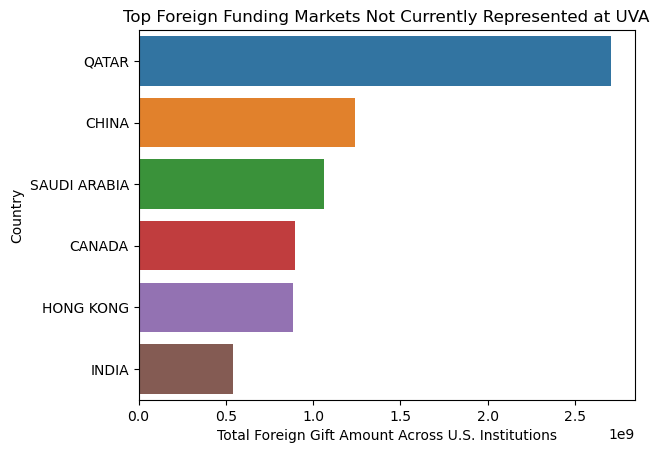

In [36]:
sns.barplot(
    x=market_opportunities.values,
    y=market_opportunities.index
)

plt.title("Top Foreign Funding Markets Not Currently Represented at UVA")
plt.xlabel("Total Foreign Gift Amount Across U.S. Institutions")
plt.ylabel("Country")

plt.show()

In [37]:
# uva's geographic peers

df["State"].value_counts().sort_index()

AL     350
AR      57
AZ     539
CA    8770
CO    1217
CT     566
DC     258
DE      40
FL      98
GA     393
HI      51
IA     105
ID      20
IL     978
IN     516
KS     167
KY     340
LA      20
MA    1756
MD    1174
ME       3
MI     995
MN     114
MO     232
MS       2
NC     466
ND       9
NE      14
NH      49
NJ     295
NM       4
NY    2625
OH    1530
OK     113
OR     169
PA    1726
RI     185
SC     107
TN      33
TX    1243
UT      83
VA     292
VT      18
WA     382
WI      63
WV      33
WY      21
Name: State, dtype: int64

In [38]:
regional = df[df["State"].isin(["VA", "MD", "DC", "NC", "WV"])]

regional_totals = (
    regional.groupby("Institution Name")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
)

regional_totals

Institution Name
Johns Hopkins University                                    502409595
Georgetown University                                       379950511
Duke University                                             343699498
George Washington University                                157668354
Virginia Commonwealth University                             89163583
George Mason University                                      65435604
University of Maryland, Baltimore                            46751866
University of North Carolina - Chapel Hill                   41292544
University of Maryland, College Park                         29933278
North Carolina State University                              23762788
University of Virginia                                       22189238
West Virginia University                                     18509865
Virginia Polytechnic Institute & State University            11792062
Catholic University of America (The)                          9423067
Wak

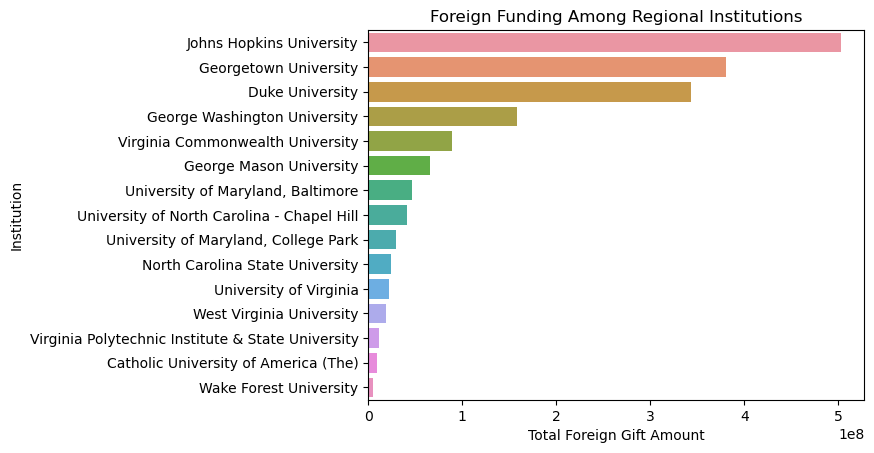

In [39]:
regional_top = regional_totals.head(15).reset_index()

sns.barplot(
    data=regional_top,
    x="Foreign Gift Amount",
    y="Institution Name"
)

plt.title("Foreign Funding Among Regional Institutions")
plt.xlabel("Total Foreign Gift Amount")
plt.ylabel("Institution")
plt.show()

UVA ranks 11th out of 23 institutions in the geographic/regional comparison. The foreign funding UVA received is less than several institutions in the area.

## Strategy for Expanding Foreign Funding at UVA

UVA has an opportunity to expand its foreign funding by targeting and building relationships with organizations and donors from countries that contribute large amounts to U.S. academic institutions but are not currently represented in UVA's foreign funding. Qatar, China, Saudi Arabia, Canada, Hong Kong, and India are among the top foreign funding countries in the overall market that are not apart of UVA's current sources. Qatar would be largest opportunity based on the dataset. They contribute $2,706,240,869 across many U.S. institutions.

Additionally, UVA currently ranks 101 out of 318 institutions in total foreign funding. The foreign funding UVA received ($22,189,238) is above the overall median of $6,486,791.5. However, it is also below the market mean of $52,202,878. If UVA were to expand into the foreign funding sources where they have no support from, then the university could increase it's foreign funding. 